# Mini Assignment 2

## Group 25

| Name | Matric No. |
| --------- | -------- |
| Goh Haw Yee | 22105316 |
| Heng Wen Yang | 22115428 |
| Yen Hua Shen | 22086174 |
| Daniel Ang Qi En | 24004519 |
| Saiket Das | 22117847 |

## Task 1: Descriptive Statistics and Correlation

- Central Tendency & Dispersion: Calculate the mean, median, and standard deviation for the key crime indicators. Detect and handle any extreme outliers in the dataset using Boxplots or statistical limits.
- Correlation Analysis: Use the .corr() method to calculate the correlation coefficient between crime rates and socio-economic factors. Visualize the relationships to identify which features have the strongest positive or negative linear correlation with crime.

In [2]:
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)

##### Load data and data quality checks

In [3]:
df = pd.read_csv("crime_statistics.csv")
print(f"Shape: {df.shape}")
display(df.head())

# Data quality
missing = df.isna().sum()
print(f"\nMissing values: {missing[missing > 0].to_dict() or 'None'}")
print(f"Duplicates: {df.duplicated().sum()}")
print(f"Season: {sorted(df['Season'].unique())}")
print(f"Police_Presence: {sorted(df['Police_Presence'].unique())}")

df_task1 = df.copy()
numeric_cols = ["Crime_Rate", "Unemployment_Rate", "Average_Income", "Education_Level", "Population_Density", "Year"]

Shape: (5000, 9)


,District,Year,Season,Unemployment_Rate,Average_Income,Education_Level,Population_Density,Police_Presence,Crime_Rate
0,District_7,2015,Winter,3.26,32197.0,13.3,2716.0,Low,23.89
1,District_20,2019,Spring,9.24,53627.0,8.3,1715.0,High,26.58
2,District_15,2017,Fall,11.16,39358.0,12.8,2710.0,Low,54.59
3,District_11,2019,Fall,4.03,69395.0,10.3,4773.0,Low,36.30
4,District_8,2022,Fall,8.53,67099.0,12.1,1801.0,Low,46.71



Missing values: None
Duplicates: 0
Season: ['Fall', 'Spring', 'Summer', 'Winter']
Police_Presence: ['High', 'Low']


##### Central tendency & dispersion analysis

In [4]:
stats = df_task1[numeric_cols].describe().T
stats.insert(2, "median", df_task1[numeric_cols].median())
stats = stats[["mean", "median", "std", "min", "25%", "50%", "75%", "max"]].round(3)
print("Central Tendency & Dispersion")
display(stats)

Central Tendency & Dispersion


,mean,median,std,min,25%,50%,75%,max
Crime_Rate,40.118,40.200,13.070,2.0,31.158,40.200,49.29,81.78
Unemployment_Rate,9.004,9.025,3.448,3.0,6.050,9.025,11.93,15.00
Average_Income,49764.439,49637.000,17272.046,20001.0,34725.000,49637.000,64390.25,79982.00
Education_Level,13.022,13.000,2.899,8.0,10.500,13.000,15.60,18.00
Population_Density,2780.330,2797.500,1289.054,500.0,1689.750,2797.500,3881.25,5000.00
Year,2019.006,2019.000,3.187,2014.0,2016.000,2019.000,2022.00,2024.00


##### Define IQR bounds function for outlier detection

In [ ]:
def iqr_bounds(s):
    q1, q3 = s.quantile(0.25), s.quantile(0.75)
    return q1 - 1.5 * (q3 - q1), q3 + 1.5 * (q3 - q1)

# Outlier detection report
rows = []
for col in numeric_cols:
    lb, ub = iqr_bounds(df_task1[col])
    n = int(((df_task1[col] < lb) | (df_task1[col] > ub)).sum())
    rows.append({"feature": col, "lower_bound": round(lb, 3), "upper_bound": round(ub, 3),
                 "outlier_count": n, "outlier_pct": round(n / len(df_task1) * 100, 2)})

print("QR Outlier Report (flagged, not removed)")
display(pd.DataFrame(rows).sort_values("outlier_count", ascending=False))

QR Outlier Report (flagged, not removed)


,feature,lower_bound,upper_bound,outlier_count,outlier_pct
0,Crime_Rate,3.959,76.489,12,0.24
1,Unemployment_Rate,-2.770,20.750,0,0.00
2,Average_Income,-9772.875,108888.125,0,0.00
3,Education_Level,2.850,23.250,0,0.00
4,Population_Density,-1597.500,7168.500,0,0.00
5,Year,2007.000,2031.000,0,0.00


##### Flag Crime_Rate outliers

In [ ]:
lb, ub = iqr_bounds(df_task1["Crime_Rate"])
df_task1["Crime_Rate_outlier"] = (df_task1["Crime_Rate"] < lb) | (df_task1["Crime_Rate"] > ub)
print(f"Crime_Rate outliers flagged: {df_task1['Crime_Rate_outlier'].sum()} / {len(df_task1)} (retained)")
display(df_task1.loc[df_task1["Crime_Rate_outlier"], ["District", "Year", "Season", "Crime_Rate"]].head(10))

Crime_Rate outliers flagged: 12 / 5000 (retained)


,District,Year,Season,Crime_Rate
99,District_5,2016,Winter,2.00
240,District_4,2016,Fall,78.17
449,District_5,2018,Winter,2.00
1718,District_12,2014,Winter,2.00
1924,District_18,2019,Winter,2.00
2058,District_10,2014,Winter,2.00
2801,District_17,2016,Summer,79.61
2804,District_8,2020,Summer,78.65
3362,District_13,2023,Summer,81.06
3393,District_15,2015,Fall,76.52


##### Boxplots for visual outlier inspection

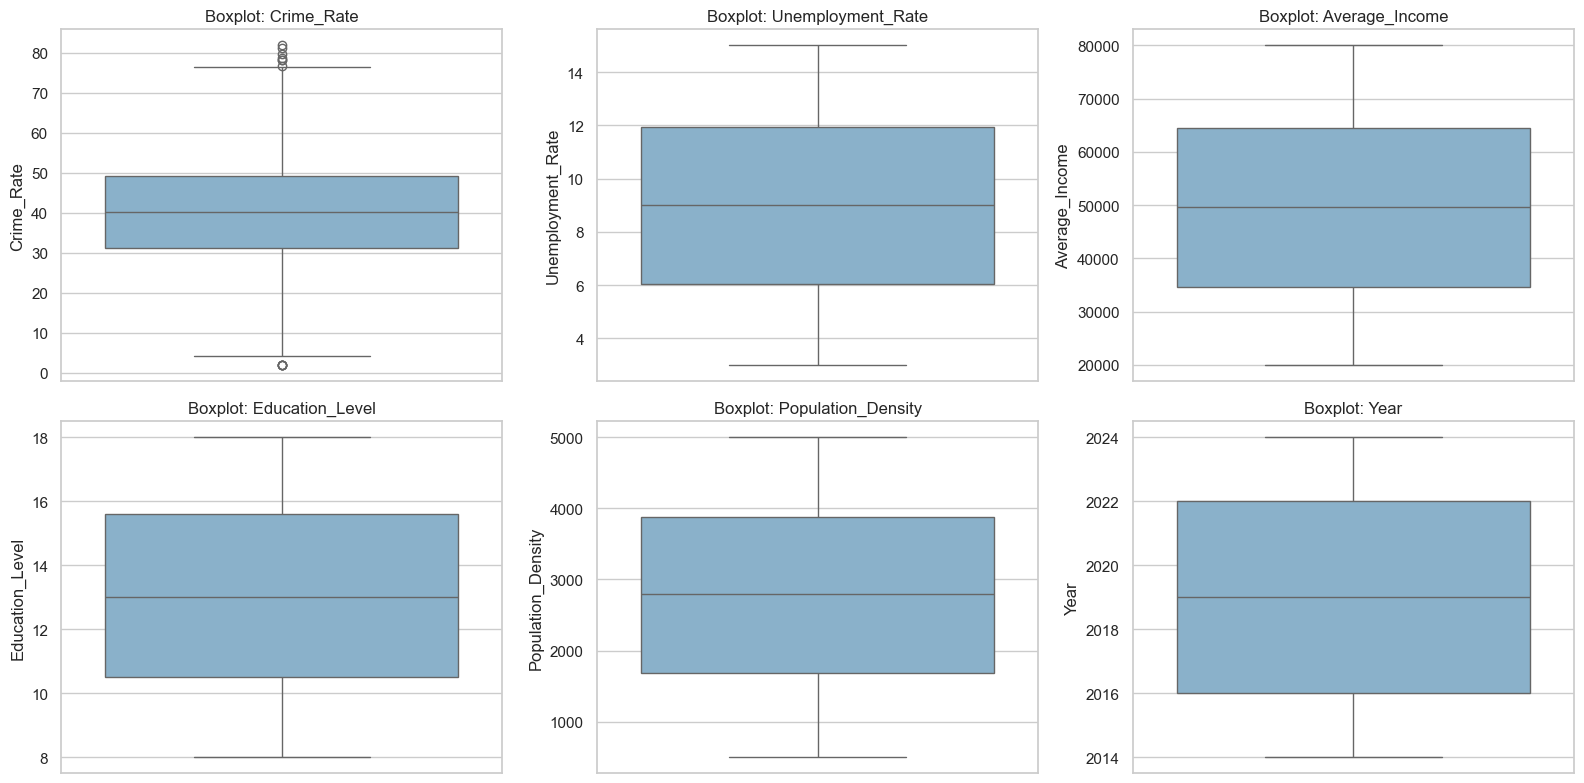

In [6]:
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
for ax, col in zip(axes.flatten(), numeric_cols):
    sns.boxplot(y=df_task1[col], ax=ax, color="#7fb3d5")
    ax.set_title(f"Boxplot: {col}")
plt.tight_layout()
plt.show()

##### Correlation analysis: encode Police_Presence and calculate correlations

In [8]:
df_task1["Police_Presence_Encoded"] = df_task1["Police_Presence"].map({"Low": 0, "High": 1})
corr_cols = ["Crime_Rate", "Unemployment_Rate", "Average_Income", "Education_Level",
             "Population_Density", "Year", "Police_Presence_Encoded"]
corr_matrix = df_task1[corr_cols].corr()
crime_corr = corr_matrix["Crime_Rate"].drop("Crime_Rate").sort_values(ascending=False)

print("Correlation Matrix")
display(corr_matrix.round(3))
print("\nCrime_Rate correlations:")
display(crime_corr.round(3).to_frame("corr_with_Crime_Rate"))

Correlation Matrix


,Crime_Rate,Unemployment_Rate,Average_Income,Education_Level,Population_Density,Year,Police_Presence_Encoded
Crime_Rate,1.000,0.649,-0.185,-0.216,0.295,-0.003,-0.370
Unemployment_Rate,0.649,1.000,0.021,0.012,-0.011,-0.011,0.000
Average_Income,-0.185,0.021,1.000,-0.003,-0.001,-0.034,0.020
Education_Level,-0.216,0.012,-0.003,1.000,-0.020,-0.015,-0.008
Population_Density,0.295,-0.011,-0.001,-0.020,1.000,0.007,-0.003
Year,-0.003,-0.011,-0.034,-0.015,0.007,1.000,0.009
Police_Presence_Encoded,-0.370,0.000,0.020,-0.008,-0.003,0.009,1.000



Crime_Rate correlations:


,corr_with_Crime_Rate
Unemployment_Rate,0.649
Population_Density,0.295
Year,-0.003
Average_Income,-0.185
Education_Level,-0.216
Police_Presence_Encoded,-0.370


##### Correlation heatmap

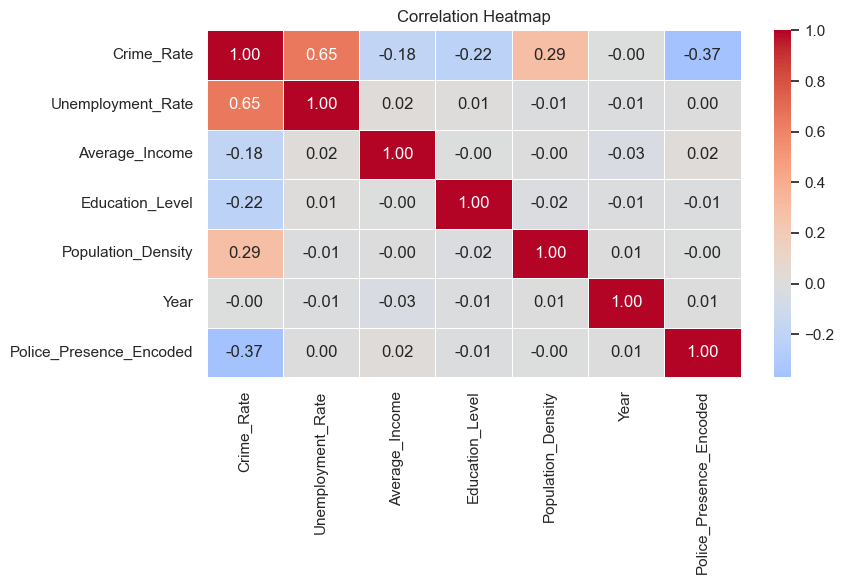

In [9]:
plt.figure(figsize=(9, 6))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", center=0, fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

##### Scatter plots: Crime_Rate vs socio-economic factors with regression lines

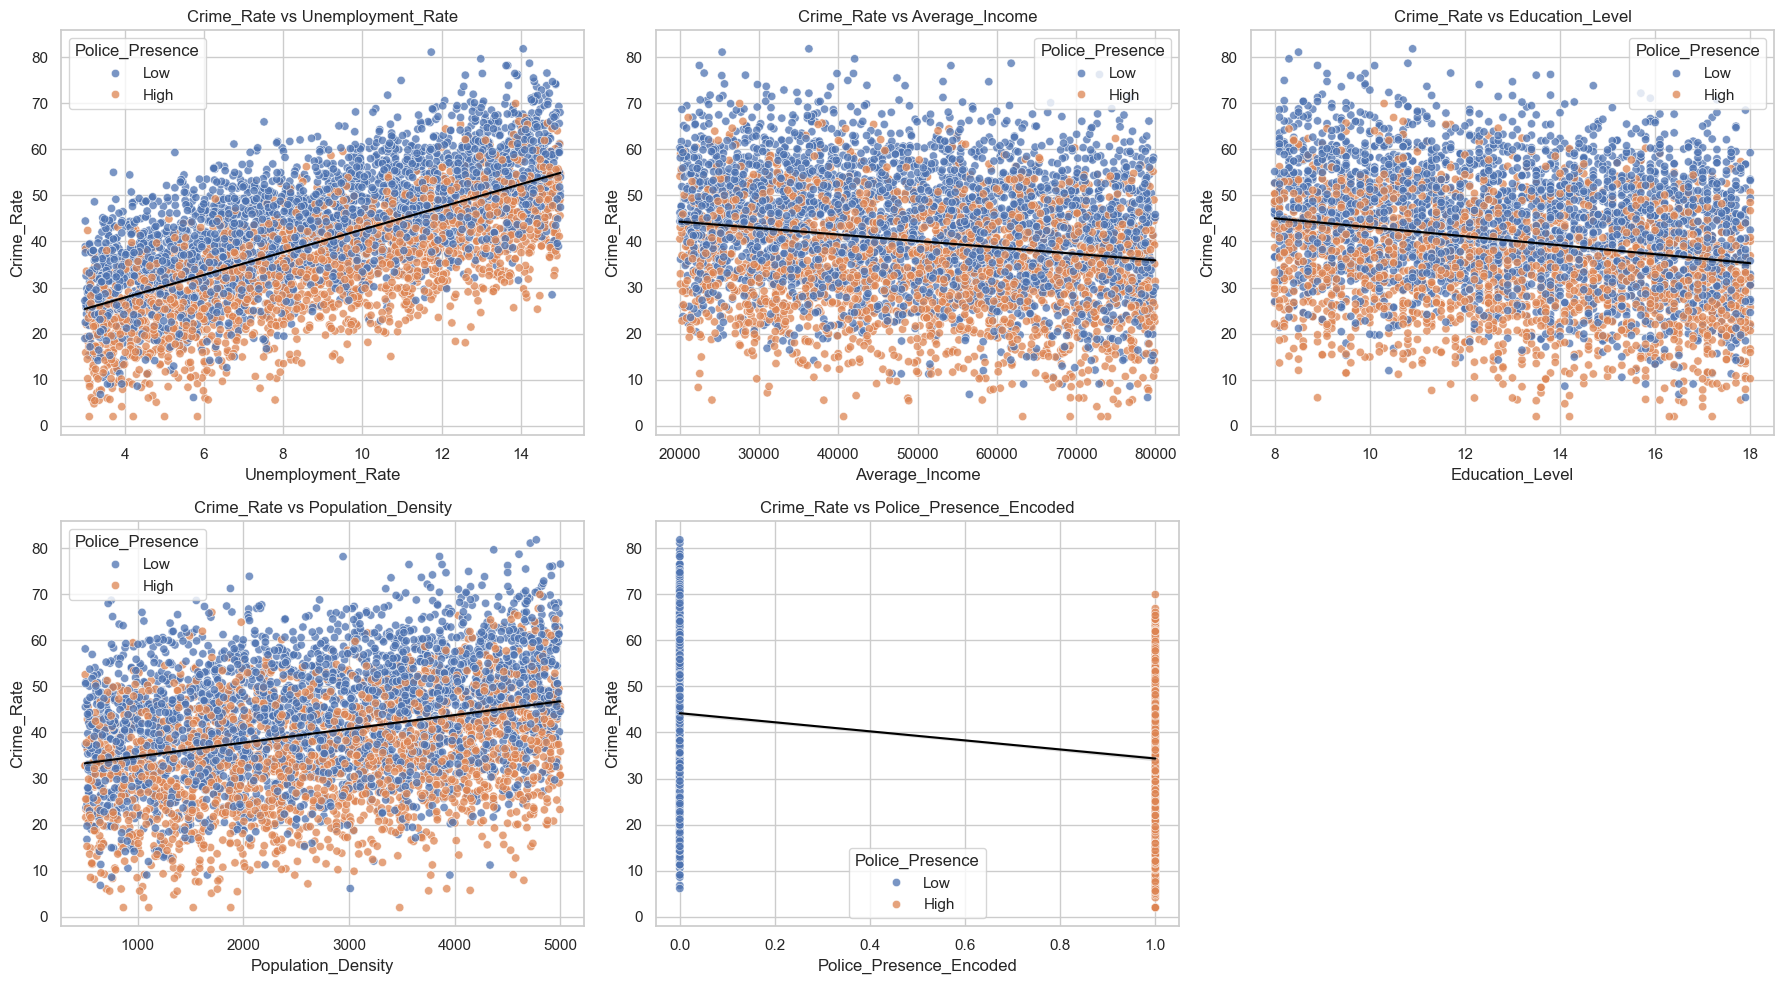

In [10]:
features = ["Unemployment_Rate", "Average_Income", "Education_Level", "Population_Density", "Police_Presence_Encoded"]
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
for ax, feat in zip(axes.flatten(), features):
    sns.scatterplot(data=df_task1, x=feat, y="Crime_Rate", hue="Police_Presence", alpha=0.75, ax=ax)
    sns.regplot(data=df_task1, x=feat, y="Crime_Rate", scatter=False, color="black", line_kws={"linewidth": 1.5}, ax=ax)
    ax.set_title(f"Crime_Rate vs {feat}")
axes.flatten()[-1].axis("off")
plt.tight_layout()
plt.show()

### Task 1 Key Findings

In [11]:
print(f"Key Findings")
print(f" - Strongest positive correlation: {crime_corr.idxmax()} ({crime_corr.max():.3f})")
print(f" - Strongest negative correlation: {crime_corr.idxmin()} ({crime_corr.min():.3f})")
print(" - Outliers flagged & retained. Correlation = linear association, not causation.")

Key Findings
 - Strongest positive correlation: Unemployment_Rate (0.649)
 - Strongest negative correlation: Police_Presence_Encoded (-0.370)
 - Outliers flagged & retained. Correlation = linear association, not causation.


#### Task 1 Findings Summary
- The dataset contains 5000 rows and 9 columns, with no missing values and no duplicate rows.
- Central tendency for Crime_Rate: mean = 40.118, median = 40.200, standard deviation = 13.070.
- Outlier detection (IQR + boxplot) identified 12 Crime_Rate outliers (0.24% of records).
- Outliers were flagged and retained (no row removal) to preserve real-world variability.
- Strongest positive linear correlation with Crime_Rate: Unemployment_Rate (r = 0.649).
- Strongest negative linear correlation with Crime_Rate: Police_Presence_Encoded (r = -0.370).
- Other relationships: Population_Density shows a moderate positive relation (r = 0.295), while Average_Income and Education_Level show weak negative relations.
- Correlation results describe linear association patterns and do not imply causation.

## Task 2: Statistical Inference and Hypothesis Testing

## Task 3: Predictive Analytics - Regression

## Task 4: Predictive Modeling - Classification & Cross-Validation

### Data Splitting

In [1]:
import sklearn as sk
import pandas as pd
import numpy as np

First, read the JSON dataset

In [2]:
patrol_logs = pd.read_json('patrol_logs.json')
patrol_logs

,Log_ID,District,Patrol_Frequency,Emergency_Calls,Previous_Incidents,Police_Staffing,Response_Time_Avg,Public_Sentiment_Score,Lighting_Quality,Event_Density,High_Risk
0,LOG-00001,District_4,26,103,78,113,24.2,7.2,3.6,8,True
1,LOG-00002,District_18,3,144,41,61,15.2,8.4,8.0,12,True
2,LOG-00003,District_14,19,116,21,63,25.3,1.1,4.0,8,True
3,LOG-00004,District_4,21,130,13,78,29.7,3.3,1.2,10,False
4,LOG-00005,District_1,6,38,42,56,8.5,4.3,1.3,7,False
...,...,...,...,...,...,...,...,...,...,...,...
9995,LOG-09996,District_6,10,28,75,88,15.6,5.1,9.6,14,True
9996,LOG-09997,District_8,9,142,8,126,36.3,7.3,7.9,4,False
9997,LOG-09998,District_18,1,52,68,88,26.9,5.1,6.5,1,False
9998,LOG-09999,District_14,8,119,39,21,42.6,2.7,3.2,5,True


'High_Risk' is the column to be predicted. Separate the JSON dataset into features (X) and target (y) and convert them to numpy arrays using .values method. Drop the non-numerical columns 'Log_ID', 'District' and the target column from the features.

In [3]:
X = patrol_logs.drop(['Log_ID', 'District', 'High_Risk'], axis=1).values
y = patrol_logs['High_Risk'].values

Split the patrol_logs.json dataset into 70% training and 30% testing sets using train_test_split() with appropriate stratification.

In [4]:
X_train, X_test, y_train, y_test = sk.model_selection.train_test_split(X, y, test_size=0.3, random_state=15, stratify=y)

### Model Building

Fit the training set to the SVM model.

In [5]:
svm = sk.svm.SVC()
svm.fit(X_train, y_train)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",False
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


Calculate the score for the SVM model.

In [6]:
svm.score(X_train, y_train)

0.8307142857142857

In [7]:
svm.score(X_test, y_test)

0.8243333333333334

Fit the training set to the Random Forest Classifier

In [8]:
rf = sk.ensemble.RandomForestClassifier()
rf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

Calculate the score for the Random Forest Classifier

In [9]:
rf.score(X_train, y_train)

1.0

In [10]:
rf.score(X_test, y_test)

0.814

### Cross-Validation & Evaluation

Use 10-fold cross-validation on both models

In [11]:
cv_svm = sk.model_selection.cross_val_score(svm, X, y, cv=10)
np.mean(cv_svm)

np.float64(0.8274000000000001)

In [12]:
cv_rf = sk.model_selection.cross_val_score(rf, X, y, cv=10)
np.mean(cv_rf)

np.float64(0.8179000000000001)

Below are the accuracy scores of both models, rounded to four decimal places

| Model | Without 10-fold CV | With 10-fold CV |
| --------- | -------- | -------- |
| SVM | 0.8243 | 0.8274 |
| Random Forest Classifier | 0.8140 | 0.8179 |

The accuracy of both models slightly improved when 10-fold cross-validation is used, with SVM being slightly more accurate than the Random Forest Classifier.

The SVM performs better in high-dimensional spaces and reduces the risk of overfitting, but the computational resources required increases for larger datasets. On the other hand, the Random Forest Classifier is non-parametric and can be applied to a variety of datasets. It usually has higher accuracy, but can be susceptible to overfitting in the training data as shown above.